# **Mineral Prospectivity Project**
## 02b National Geochemical Database (NGDB) exploratory data analysis

goals:\
-create plots and maps to investigate distributions, correlations and spatial trends

### Part 1. import packages and identify local directory
a. import packages needed for data loading and analysis

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import glob
import os

data_path = "/Users/adbyerly/prospectivity_model/data/processed/"

### Part 2. load processed data

In [ ]:
# csv - load all geochemical files from the processed folder into a dictionary
files = glob.glob(data_path + "NGDB/*.csv")
ngdb_dfs_processed={}

for file in files:
    name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file, low_memory=False)
    ngdb_dfs_processed[name] = df

ngdb_dfs_processed.keys()

In [ ]:
# examine processed dataframes

for name, df in ngdb_dfs_processed.items():
    print(name)
    print(df.head())
    print(df.columns)
    print(df.shape)
    print("-" * 25)

### Part 3. investigate data and document observations

a. start with the "Rock Data" dataframe which contains information about the samples

In [43]:
# set variable for this table
rockdata = ngdb_dfs_processed['Rock_Data']

print(rockdata.head())
print(rockdata.columns)
print(rockdata.dtypes)

   lab_id job_id         submitter    date_sub field_id state        country  \
0  AAV161   HM42  Gott, Garland B.  19660721.0    CD008    ID  United States   
1  AAV162   HM42  Gott, Garland B.  19660721.0   CD008A    ID  United States   
2  AAV163   HM42  Gott, Garland B.  19660721.0    CD009    ID  United States   
3  AAV164   HM42  Gott, Garland B.  19660721.0   CD009A    ID  United States   
4  AAV165   HM42  Gott, Garland B.  19660721.0    CD010    ID  United States   

  original_datum spheroid  latitude  ...  struct_src dep_envirn source_rk  \
0          NAD27      NaN  47.47778  ...         NaN        NaN       NaN   
1          NAD27      NaN  47.47778  ...         NaN        NaN       NaN   
2          NAD27      NaN  47.47667  ...         NaN        NaN       NaN   
3          NAD27      NaN  47.47667  ...         NaN        NaN       NaN   
4          NAD27      NaN  47.47556  ...         NaN        NaN       NaN   

  metamrphsm facies_grd prep mesh_size Unnamed: 31  \
0 

In [53]:
# general observations about sample quantity and locations

print ('There are ' + str(len(rockdata)) + ' samples.')

# print(rockdata['depth'].nunique())
# print(rockdata['depth'].unique())

# observation --------
print('All samples are effectively from the surface.')

print('Samples come from ' + str(rockdata['locat_desc'].nunique()) + ' locations.')

There are 26521 samples.
All samples are effectively from the surface.
Samples come from 214 locations.


<StringArray>
['rock']
Length: 1, dtype: str
<StringArray>
['metamorphic', nan, 'sedimentary', 'igneous', 'unidentified']
Length: 5, dtype: str
xndryclass
igneous         13095
metamorphic      6249
sedimentary      4527
NaN              2392
unidentified      258
Name: count, dtype: int64


<Axes: xlabel='xndryclass'>

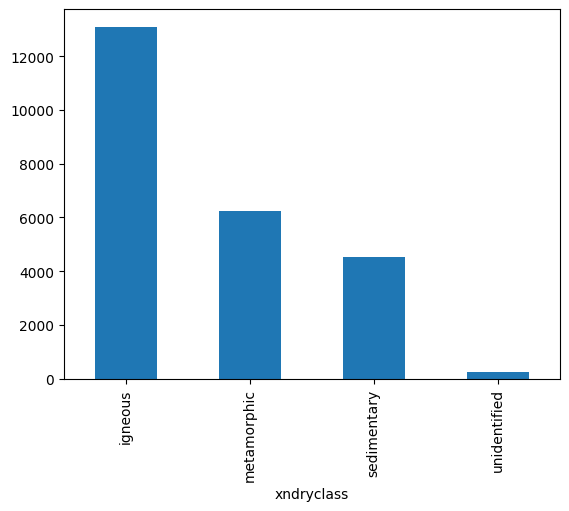

In [71]:
# identify types of rocks



# -------- these don't contain apparently useful information
# print(rockdata['source_rk'].nunique())
# print(rockdata['source_rk'].unique())
# print(rockdata['source_rk'].value_counts(dropna=False))

# print(rockdata['sample_src'].nunique())
# print(rockdata['sample_src'].unique())

# print(rockdata['metamrphsm'].nunique())
# print(rockdata['metamrphsm'].unique())
# -------- these don't contain apparently useful information



# 'xnddryclass' feature contains information about the rock type
print(rockdata['primeclass'].unique())
print(rockdata['xndryclass'].unique())
print(rockdata['xndryclass'].value_counts(dropna=False))

rockdata['xndryclass'].value_counts().plot(kind='bar')

In [78]:
# examine ages of igneous rocks

mask = rockdata['xndryclass'] == 'igneous'
igneous = rockdata[mask]

print(igneous['geol_age'].nunique())
print(igneous['geol_age'].unique().tolist())

80
[nan, 'Cretaceous', 'Precambrian undifferentiated', 'tertiary undifferentiated', 'cretaceous', 'eocene', 'jurassic', 'mesozoic undifferentiated', 'Tertiary', 'Quaternary', 'tertiary', 'late precambrian', 'cretaceous--tertiary', 'mesozoic', 'Middle Precambrian', 'Unknown', 'Eocene', 'Late Precambrian', 'pliocene--quaternary', 'pliocene--pleistocene', 'pleistocene', 'holocene', 'quaternary', 'pliocene', 'miocene', 'pennsylvanian--triassic', 'miocene--pliocene', 'miocene--pleistocene', 'paleocene--miocene', 'precambrian undifferentiated', 'cretaceous--eocene', 'mesozoic--tertiary', 'precambrian undiff--eocene', 'paleozoic', 'tertiary--quaternary', 'jurassic--cretaceous', 'eocene--oligocene', 'ordovician--silurian', 'oligocene--miocene', 'precambrian undiff--tertiary', 'permian--jurassic', 'permian', 'permian--triassic', 'oligocene', 'late precambrian--paleozoic', 'late precambrian--paleocene', 'cretaceous--miocene', 'ordovician', 'late precambrian--cretaceous', 'late precambrian--eocen

In [81]:
print(igneous['spec_name'].unique().tolist())

['mafic', 'monzonite', 'granite', 'felsic', 'dacite', 'porphyry', 'felsite', 'adamellite', 'latite', 'tonalite', 'rhyolite', 'granodiorite', 'quartz', 'intermediate', 'andesite', 'welded tuff', 'aplite', 'pegmatite', 'tuff', 'basalt', 'ultramafic', 'feldspathoidal', nan, 'rhyodacite', 'quartz diorite', 'diorite', 'quartz monzonite', 'felsic igneous', 'gabbro', 'obsidian', 'ash', 'syenite', 'pumice', 'olivine basalt', 'diabase', 'quartz latite', 'TUFF', 'WELDED TUFF', 'volcanic glass', 'unknown', 'alaskite', 'carbonatite', 'RHYODACITE', 'FELSITE', 'PERLITE', 'PUMICE', 'RHYOLITE', 'pyroxenite', 'amphibolite', 'BASALT', 'GRANODIORITE', 'trachyte', 'lamprophyre', 'DIORITE', 'alkalic', 'BRECCIA', 'PEGMATITE', 'gneiss', 'ANDESITE', 'DACITE', 'SCORIA', 'VITROPHYRE', 'GABBRO', 'monzodiorite', 'QUARTZ', 'TONALITE', 'MONZONITE', 'trap', 'hornblendite', 'syenite/nepheline', 'malignite', 'minette', 'leucogranite', 'augen gneiss', 'AUGEN GNEISS', 'orthogneiss', 'schist', 'syenogranite', 'breccia']
